# Generative Adversarial Networks

In class we looked at autoencoders as a way of performing dimensionality reduction and variational autoencoders as a way of learning latent space representations to generate synthetic data. In this homework we'll look at an alternative way to generate synthetic data from a latent space: _generative adversarial networks_ or GANs. Recall that in variational autoencoders we trained two networks simultaneously: an encoder and a decoder. For GANs we will also be training two networks together, a _generator_ and a _discriminator_. The generator will be the same as the decoder we used for autoencoders--it takes random value from the latent space and outputs a synthetic image. The discriminator is new. It takes an image and tries to guess whether that point is real data from the dataset or fake data generated by the generator.

The word "adversarial" in generative adversarial networks refers to the way we train the generator and the discriminator. These two networks are combating each other: the discriminator is trying to spot synthetic images from the generator and the generator is trying to fool the discriminator. More formally, the discriminator is performing a normal binary classification task (images are classified as either real or fake) so it has a normal binary cross entropy loss. The generator's loss is defined by how well it fools the discriminator. Formally, we ask the descriminator to classify a batch of synthetic images but then we measure the binary cross entropy loss using the label "real". If the loss is high, that means the discriminator (correctly) labeled those images as fake. If the loss is low, then the discriminator labeled the images as real, which is what the generator wants.

Mathematically, we'll sample real images $x_R \sim \mathcal{D}$ for our dataset $\mathcal{D}$ and we'll also sample $x_F \sim G(z)$ where $G$ is our generator network and $z$ is random noise (typically sampled from standard normal distribution). We label $x_R$ with label 0 (not fake) and $x_F$ with label 1 (fake). The discriminator is trained to predict these labels using a normal binary cross entropy loss. The generator's loss is computed based on how effective the discriminator is on fake images. The typical way to do this is to compute the binary cross entropy loss with the labels inverted, so the loss of $G$ for a generated image $x_F$ and discriminator $D$ is

$$
\ell(G) = BCEWithLogitsLoss(D(x_F), 0)
$$

First, our normal suite of imports.

In [61]:
import torch
from torch import nn, optim
import numpy as np
import torchvision
import torchvision.transforms.v2 as transforms
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import torch.utils.tensorboard as tb
%matplotlib inline
%config InlineRenderer.figure_format = 'retina'

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = 'cpu'
print(device)

mps


We'll continue to use the Fashion MNIST dataset that we looked at in class.

In [62]:
transform = transforms.Compose([
    transforms.ToImage(),
    transforms.ConvertImageDtype(),
])

data = torchvision.datasets.FashionMNIST('fashion_mnist', download=True, transform=transform)
train_size = int(0.8 * len(data))
train_data, valid_data = torch.utils.data.random_split(data, [train_size, len(data) - train_size])

Here you need to set up your two models. The descriminator is a binary classifier and the generator will be similar to the decoders from our autoencoder notebooks.

One hint here: sometimes the discriminator can be _too_ good, such that the generator is unable to learn anything because no matter what it tries, the discriminator can always find the fake images. If you're finding that the discriminator loss is always very small and the generator isn't learning anything, one thing you can try is making the discriminator smaller and less powerful. However, if you go too far then the generator is able to fool the discriminator even with low-quality fakes that don't look real to humans, so there is a balance to be struck.

In [63]:
class Discriminator(nn.Module):

    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(1, 8, (7, 7), padding=3),
            nn.ReLU(),
            nn.Conv2d(8, 16, 3, padding=1),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.AvgPool2d(kernel_size=3),
            nn.Flatten(),
            nn.Linear(32*4*4, 1)
        )

    def forward(self, x):
        return self.model(x).squeeze(dim=1)


class Generator(nn.Module):

    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 3),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, 3, stride=2),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 8, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(8, 1, 7, stride=2, padding=3, output_padding=1)
        )
    
    def forward(self, z):
        return self.model(z)

As always, it may be useful to log some data.

In [64]:
log_dir = 'gan_logs'

# Load the tensorboard extension for Jupyter
%load_ext tensorboard
# Start tensorboard and tell it where to look for logs. It will auto-update every second.
%tensorboard --logdir {log_dir} --reload_interval 1 

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Now it's time to set up your training code.

In [75]:
def train(lr=1e-3, epochs=10, batch_size=32):
    gen = Generator().to(device)
    dis = Discriminator().to(device)

    dis_loss = nn.BCEWithLogitsLoss()
    
    loader = torch.utils.data.DataLoader(train_data, shuffle=True, batch_size=batch_size)
    valid_loader = torch.utils.data.DataLoader(valid_data, shuffle=False, batch_size=batch_size)

    logger = tb.SummaryWriter(log_dir)
    global_step = 0

    gen_optim = optim.Adam(gen.parameters(), lr=lr)
    dis_optim = optim.Adam(dis.parameters(), lr=lr)

    # We'll plot the output of the generator for the same noise values at different
    # points in training using Tensorboard. That will let us see how our generated
    # images change over time.
    noise = torch.normal(0, 1, (10, 64, 1, 1)).to(device)

    for i in tqdm(range(epochs)):
        gen.train()
        dis.train()
        for batch, _ in loader:
            real_batch = batch.to(device)
            z_noise = torch.normal(mean=0, std=1, size=(batch.shape[0], 64, 1, 1))
            z = z_noise.to(device)
            fake_batch = gen(z)   # Generate synthetic images from the generator

            fake_preds = dis(fake_batch)

            loss_val = dis_loss(fake_preds, torch.zeros(batch_size).to(device))   # Compute a loss value for the generator 
            gen_optim.zero_grad()
            loss_val.backward()
            gen_optim.step()

            # This batch includes both real and fake images
            batch = torch.cat((real_batch, fake_batch.detach()))
            labels = torch.cat((torch.zeros(batch_size), torch.ones(batch_size))).to(device)

            preds = dis(batch)
            loss_val = dis_loss(preds, labels)   # Compute a loss value for the discriminator
            
            logger.add_scalar('train_loss', loss_val, global_step=global_step)
            global_step += 1
            dis_optim.zero_grad()
            loss_val.backward()
            dis_optim.step()

        gen.eval()
        dis.eval()
        print("Epoch:", i)
        gen_imgs = gen(noise)   # Generate images from our fixed noise samples
        logger.add_images('generated', gen_imgs, global_step=global_step)
    
    return gen, dis

In [76]:
generator, discriminator = train(epochs=15)

  0%|          | 0/15 [00:00<?, ?it/s]

Epoch: 0
Epoch: 1
Epoch: 2
Epoch: 3
Epoch: 4
Epoch: 5
Epoch: 6
Epoch: 7
Epoch: 8
Epoch: 9
Epoch: 10
Epoch: 11
Epoch: 12
Epoch: 13
Epoch: 14


Let's finish by visualizing some of your synthetic data.

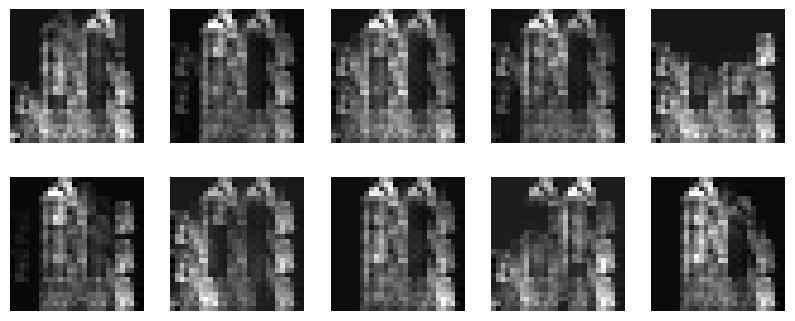

In [92]:
generator = generator.cpu()

fig, axs = plt.subplots(2, 5, figsize=(10, 4))
for i in range(10):
    z_noise = torch.normal(mean=0, std=1, size=(1, 64, 1, 1))
    z = z_noise
    img = generator(z)   # Generate an image from the generator
    axs[i//5][i%5].imshow(img.detach().numpy().squeeze(), cmap='gray')
    axs[i//5][i%5].set_axis_off()
plt.show()
# We discovered they converge at the end which is why it all looks the same but throughout the training they look substantially different
# I'm not sure still why it is converging but the process seems relavitely correct to me